In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv

In [2]:
load_dotenv()
model = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.1
)

In [3]:
class BlogState(TypedDict):

    title: str
    outline: str
    content: str

In [5]:
def create_outline(state: BlogState) -> BlogState:

    # fetch title
    title = state['title']

    # call llm gen outline
    prompt = f'Generate a detailed outline for a blog on the topic - {title}'
    outline = model.invoke(prompt).content

    # update state
    state['outline'] = outline

    return state

In [6]:
def create_blog(state: BlogState) -> BlogState:

    title = state['title']
    outline = state['outline']

    prompt = f'Write a detailed blog on the title - {title} using the follwing outline \n {outline}'

    content = model.invoke(prompt).content

    state['content'] = content

    return state

In [7]:
graph = StateGraph(BlogState)

# nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

workflow = graph.compile()


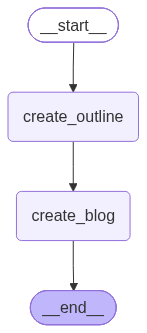

In [8]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [9]:
intial_state = {'title': 'Rise of Pollution in India'}

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of Pollution in India', 'outline': '**Blog Title:**  \n*The Rise of Pollution in India: Causes, Consequences, and the Road Ahead*  \n\n**Target Length:** 2,200\u202f–\u202f2,800\u202fwords  \n**Primary Keywords:** pollution in India, air pollution India, water pollution India, Indian environmental crisis, India climate change, Indian government pollution policies  \n**Secondary Keywords:** smog Delhi, plastic waste India, river pollution Ganga, industrial emissions India, health impacts pollution, sustainable solutions India  \n\n---\n\n## 1. Introduction (≈200‑250\u202fwords)\n\n- **Hook:** A vivid, recent snapshot (e.g., “When you step out of a Delhi metro station, the sky looks like a hazy watercolor…”).  \n- **Why it matters:** Brief statistics on India’s ranking in global pollution indexes (e.g., WHO air quality, World Bank water quality).  \n- **Thesis statement:** Outline that the post will explore the *why*, *how*, and *what now* of India’s escalating pollution 

In [10]:
print(final_state['outline'])

**Blog Title:**  
*The Rise of Pollution in India: Causes, Consequences, and the Road Ahead*  

**Target Length:** 2,200 – 2,800 words  
**Primary Keywords:** pollution in India, air pollution India, water pollution India, Indian environmental crisis, India climate change, Indian government pollution policies  
**Secondary Keywords:** smog Delhi, plastic waste India, river pollution Ganga, industrial emissions India, health impacts pollution, sustainable solutions India  

---

## 1. Introduction (≈200‑250 words)

- **Hook:** A vivid, recent snapshot (e.g., “When you step out of a Delhi metro station, the sky looks like a hazy watercolor…”).  
- **Why it matters:** Brief statistics on India’s ranking in global pollution indexes (e.g., WHO air quality, World Bank water quality).  
- **Thesis statement:** Outline that the post will explore the *why*, *how*, and *what now* of India’s escalating pollution problem.  
- **Road‑map sentence:** Preview the main sections (causes, types, impacts

In [10]:
print(final_state['content'])

I. Introduction

A. Artificial Intelligence (AI) is a branch of computer science that aims to create intelligent machines that can perform tasks that typically require human intelligence. These tasks can include speech recognition, decision-making, visual perception, and more. 

B. The field of AI has been steadily growing in India over the past few years, with advancements being made in various industries such as healthcare, finance, education, and more. 

C. The purpose of this blog is to explore the rise of AI in India and its implications on the economy, job market, society, and culture.

II. Historical Context of AI in India

A. India has a rich history in AI research, with institutions like the Indian Institute of Technology (IIT) and the Indian Statistical Institute (ISI) making significant contributions to the field. 

B. The Indian government has also taken steps to promote AI development in the country, with initiatives like the National AI Portal and the National Mission on 